In [1]:
libraries<-c("DESeq2","ggplot2","viridis","RColorBrewer","pheatmap","edgeR","ggfortify","factoextra")
suppressPackageStartupMessages(lapply(libraries, require, character.only = TRUE)) 

[[1]]
[1] TRUE

[[2]]
[1] TRUE

[[3]]
[1] TRUE

[[4]]
[1] TRUE

[[5]]
[1] TRUE

[[6]]
[1] TRUE

[[7]]
[1] TRUE

[[8]]
[1] TRUE

In [ ]:
#Countfile 
countData <- read.delim("your_path/count_matrix.tsv",
                        sep = "\t",
                        row.names = 1,
                        comment.char = "#")

countData[,1] <- NULL

In [ ]:
#Metadata
#sampledatainfo.txt file was a table with metadata info, similar to: 
#sample	hpi	genotype	biosample	response	tissue	treatment
#C195_60H_1	060HPI	C195	R1	Susceptible	hypocotyl	C195_060HPI
#C195_60H_2	060HPI	C195	R2	Susceptible	hypocotyl	C195_060HPI

samples <- read.delim("your_path/sampledatainfo.txt",
                      header=T)

In [ ]:
#create groups based in treatment
groups<-samples$treatment

In [8]:
groups

[1] "C195_060HPI" "C195_060HPI" "C195_060HPI" "C195_060HPI" "C195_084HPI"
 [6] "C195_084HPI" "C195_084HPI" "C195_084HPI" "C195_024HPI" "C195_024HPI"
[11] "C195_024HPI" "C195_024HPI" "C195_000HPI" "C195_000HPI" "C195_000HPI"
[16] "C195_000HPI" "C98_060HPI"  "C98_060HPI"  "C98_060HPI"  "C98_060HPI" 
[21] "C98_084HPI"  "C98_084HPI"  "C98_084HPI"  "C98_084HPI"  "C98_024HPI" 
[26] "C98_024HPI"  "C98_024HPI"  "C98_024HPI"  "C98_000HPI"  "C98_000HPI" 
[31] "C98_000HPI"  "C98_000HPI"

In [ ]:
#Run  DGEList 
#DGEList: is a central structure to edgeR.
#counts = rows must be genes and columns samples

d <- DGEList(counts=countData,group=factor(groups))

In [10]:
# Filter lowly expressed genes
keep <- filterByExpr(d)
d <- d[keep, , keep.lib.sizes=FALSE]

In [ ]:
#check total genes and samples
dim(d)

[1] 33255    32

In [ ]:
d.full <- d # keep the old one in case we mess up
dim(d)

d$samples$lib.size <- colSums(d$counts)

d_cpm <- calcNormFactors(d,method = "none")

cpms<-cpm(d_cpm, log=FALSE,normalized.lib.sizes = T)
cpml<-cpm(d_cpm,log = TRUE,normalized.lib.sizes = T)


[1] 33255    32

In [ ]:
#TMM (Trimmed Mean of M-values) normalization
d_TMM <- calcNormFactors(d, method="TMM")

In [ ]:
#Calculate the cpm with the TMM normalized library
TMM <- cpm(d_TMM, log = FALSE, normalized.lib.sizes=TRUE)
tmm_log <- log(1+TMM)

In [ ]:
write.table(cpms,file = "your_path/Counts_cpms.tsv",sep = '\t',quote = F)
write.table(cpml,file = "your_path/Counts_cpml.tsv",sep = '\t',quote = F)
write.table(TMM,file = "your_path/Counts_tmm.tsv",sep = '\t',quote = F)
write.table(tmm_log,file = "your_path/Counts_tmm_log.tsv",sep = '\t',quote = F)

In [ ]:
# Normalize the data
d <- calcNormFactors(d)

In [ ]:
#Create a design matrix to specify the model.
design <- model.matrix(~ 0 + groups)  
colnames(design) <- levels(as.factor(groups))

In [ ]:
# Estimate dispertion
y <- estimateDisp(d, design)

In [ ]:
# Fit the model
fit <- glmQLFit(y, design)

In [30]:
colnames(design)

[1] "C195_000HPI" "C195_024HPI" "C195_060HPI" "C195_084HPI" "C98_000HPI" 
[6] "C98_024HPI"  "C98_060HPI"  "C98_084HPI"

In [ ]:
#makeContrast edgeR
#glmQLFTest: Test quasi-likelihood F-test
#top: extract and sort by significance 
#contrast: your_treatment_sample vs your_control_sample
contrast1 <- makeContrasts(C195_024HPI_vs_C195_000HPI = C195_024HPI - C195_000HPI, levels = design)
qlf1 <- glmQLFTest(fit, contrast = contrast1)
top1 <- topTags(qlf1, n = Inf)

In [32]:
contrast2 <- makeContrasts(C195_060HPI_vs_C195_000HPI = C195_060HPI - C195_000HPI, levels = design)
qlf2 <- glmQLFTest(fit, contrast = contrast2)
top2 <- topTags(qlf2, n = Inf)

In [33]:
contrast3 <- makeContrasts(C195_084HPI_vs_C195_000HPI = C195_084HPI - C195_000HPI, levels = design)
qlf3 <- glmQLFTest(fit, contrast = contrast3)
top3 <- topTags(qlf3, n = Inf)


In [34]:
contrast4<- makeContrasts(C98_024HPI_vs_C98_000HPI = C98_024HPI - C98_000HPI, levels = design)
qlf4 <- glmQLFTest(fit, contrast = contrast4)
top4 <- topTags(qlf4, n = Inf)


In [35]:
contrast5<- makeContrasts(C98_060HPI_vs_C98_000HPI = C98_060HPI - C98_000HPI, levels = design)
qlf5 <- glmQLFTest(fit, contrast = contrast5)
top5 <- topTags(qlf5, n = Inf)


In [36]:
contrast6<- makeContrasts(C98_084HPI_vs_C98_000HPI = C98_084HPI - C98_000HPI, levels = design)
qlf6 <- glmQLFTest(fit, contrast = contrast6)
top6 <- topTags(qlf6, n = Inf)


In [ ]:
# Save the top results to a TSV file
write.table(as.data.frame(top1), file = "your_path/EdgeRC195_024HPI_vs_C195_000HPI_all.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(top2), file = "your_path/EdgeR_C195_060HPI_vs_C195_000HPI_all.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(top3), file = "your_path/EdgeR_C195_084HPI_vs_C195_000HPI_all.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(top4), file = "your_path/EdgeR_C98_024HPI_vs_C98_000HPI_all.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(top5), file = "your_path/EdgeR_C98_060HPI_vs_C98_000HPI_all.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(top6), file = "your_path/EdgeR_C98_084HPI_vs_C98_000HPI_all.tsv", sep = "\t", quote = FALSE, row.names = TRUE)

In [ ]:
#Filter by differential expression

DE_list_C195_024HPI_vs_C195_000HPI <- subset(top1$table, FDR < 0.05 & logFC>= 2 | FDR < 0.05 & logFC <= -2)
DE_list_C195_060HPI_vs_C195_000HPI <- subset(top2$table, FDR < 0.05 & logFC>= 2 | FDR < 0.05 & logFC <= -2)
DE_list_C195_084HPI_vs_C195_000HPI <- subset(top3$table, FDR < 0.05 & logFC>= 2 | FDR < 0.05 & logFC <= -2)
DE_list_C98_024HPI_vs_C98_000HPI <- subset(top4$table, FDR < 0.05 & logFC>= 2 | FDR < 0.05 & logFC <= -2)
DE_list_C98_060HPI_vs_C98_000HPI <- subset(top5$table, FDR < 0.05 & logFC>= 2 | FDR < 0.05 & logFC <= -2)
DE_list_C98_084HPI_vs_C98_000HPI <- subset(top6$table, FDR < 0.05 & logFC>= 2 | FDR < 0.05 & logFC <= -2)


In [ ]:
# Save the results to a TSV file
write.table(as.data.frame(DE_list_C195_024HPI_vs_C195_000HPI), file = "your_path/EdgeR_C195_024HPI_vs_C195_000HPI_DE.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(DE_list_C195_060HPI_vs_C195_000HPI), file = "your_path/EdgeR_C195_060HPI_vs_C195_000HPI_DE.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(DE_list_C195_084HPI_vs_C195_000HPI), file = "your_path/EdgeR_C195_084HPI_vs_C195_000HPI_DE.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(DE_list_C98_024HPI_vs_C98_000HPI), file = "your_path/EdgeR_C98_024HPI_vs_C98_000HPI_DE.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(DE_list_C98_060HPI_vs_C98_000HPI), file = "your_path/EdgeR_C98_060HPI_vs_C98_000HPI_DE.tsv", sep = "\t", quote = FALSE, row.names = TRUE)
write.table(as.data.frame(DE_list_C98_084HPI_vs_C98_000HPI), file = "your_path/EdgeR_C98_084HPI_vs_C98_000HPI_DE.tsv", sep = "\t", quote = FALSE, row.names = TRUE)


In [ ]:
#DESEQ2:
#Check columns of counts must be in the same order that rows in the samples object

d$counts
samples

In [ ]:
#DESEQ2 design
dds <- DESeqDataSetFromMatrix(countData=d$counts, 
                              colData=samples, 
                              design= ~ genotype  + hpi + hpi:genotype)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [43]:
dds$genotype<-as.factor(dds$genotype)
dds$hpi<-as.factor(dds$hpi)
dds$tissue<-as.factor(dds$tissue)

In [ ]:
dds$group <- factor(paste0(dds$hpi, dds$genotype, dds$tissue))

In [ ]:
design(dds) <- ~ group

In [ ]:
#if you can, change parallel=TRUE
dds <- DESeq(dds,parallel = FALSE) 

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [47]:
res<-results(dds, cooksCutoff=FALSE, independentFiltering=FALSE)

In [ ]:
#Create directories to plots and tables
path<-"your_path/"
dir.create(paste0(path,"/plots"),recursive = FALSE,showWarnings = FALSE)
plots<-paste0(path,"/plots")

dir.create(paste0(path,"/tables"),recursive = FALSE,showWarnings = FALSE)
tables<-paste0(path,"/tables")

In [ ]:
#DESEQ2 Contrast C195 genotype 
#your_treatment_sample (as: 024HPIC195hypocotyl) vs control (as: 000HPIC195hypocotyl)

ct_24hpiHC195<-results(dds, contrast=c("group","024HPIC195hypocotyl","000HPIC195hypocotyl"))
ct_24hpiHC195 <- ct_24hpiHC195[order(ct_24hpiHC195$padj),]
ct_24hpiHC195_filtered<-ct_24hpiHC195[which(ct_24hpiHC195$padj  < 0.01),]
DE_list_ct_24hpiHC195 <- subset(ct_24hpiHC195_filtered, padj < 0.01 & log2FoldChange>= 2 | padj < 0.01 & log2FoldChange <= -2)


write.table(as.data.frame(ct_24hpiHC195), 
            file= paste(tables,"DESEQ_ctVS24hpiHypocotylC195_all.tsv",sep = "/"),
            sep = "\t",quote = F)

write.table(as.data.frame(DE_list_ct_24hpiHC195), 
              file=paste(tables,"DESEQ_ctVS24hpiHypocotylC195_DE.tsv",sep = "/"),
              sep = "\t")

ct_60hpiHC195<-results(dds, contrast=c("group","060HPIC195hypocotyl","000HPIC195hypocotyl"))
ct_60hpiHC195 <- ct_60hpiHC195[order(ct_60hpiHC195$padj),]
ct_60hpiHC195_filtered<-ct_60hpiHC195[which(ct_60hpiHC195$padj  < 0.01),]
DE_list_ct_60hpiHC195 <- subset(ct_60hpiHC195_filtered, padj < 0.01 & log2FoldChange>= 2 | padj < 0.01 & log2FoldChange <= -2)


write.table(as.data.frame(ct_60hpiHC195), 
            file= paste(tables,"DESEQ_ctVS60hpiHypocotylC195_all.tsv",sep = "/"),
            sep = "\t",quote = F)

write.table(as.data.frame(DE_list_ct_60hpiHC195), 
              file=paste(tables,"DESEQ_ctVS60hpiHypocotylC195_DE.tsv",sep = "/"),
              sep = "\t")


ct_84hpiHC195<-results(dds, contrast=c("group","084HPIC195hypocotyl","000HPIC195hypocotyl"))
ct_84hpiHC195 <- ct_84hpiHC195[order(ct_84hpiHC195$padj),]
ct_84hpiHC195_filtered<-ct_84hpiHC195[which(ct_84hpiHC195$padj  < 0.01),]
DE_list_ct_84hpiHC195 <- subset(ct_84hpiHC195_filtered, padj < 0.01 & log2FoldChange>= 2 | padj < 0.01 & log2FoldChange <= -2)

write.table(as.data.frame(ct_84hpiHC195), 
            file= paste(tables,"DESEQ_ctVS84hpiHypocotylC195_all.tsv",sep = "/"),
            sep = "\t",quote = F)

write.table(as.data.frame(DE_list_ct_84hpiHC195), 
              file=paste(tables,"DESEQ_ctVS84hpiHypocotylC195_DE.tsv",sep = "/"),
              sep = "\t")

In [ ]:
#DESEQ2 Contrast C98 genotype 
#your_treatment_sample (as: 024HPIC98hypocotyl) vs control (as: 000HPIC98hypocotyl)


ct_24hpiH<-results(dds, contrast=c("group","024HPIC98hypocotyl","000HPIC98hypocotyl"))
ct_24hpiH <- ct_24hpiH[order(ct_24hpiH$padj),]
ct_24hpiH_filtered<-ct_24hpiH[which(ct_24hpiH$padj  < 0.01),]
DE_list_ct_24hpiH <- subset(ct_24hpiH_filtered, padj < 0.01 & log2FoldChange>= 2 | padj < 0.01 & log2FoldChange <= -2)


write.table(as.data.frame(ct_24hpiH), 
            file= paste(tables,"DESEQ_ctVS24hpiHypocotylC98_all.tsv",sep = "/"),
            sep = "\t",quote = F)

write.table(as.data.frame(DE_list_ct_24hpiH), 
              file=paste(tables,"DESEQ_ctVS24hpiHypocotylC98_DE.tsv",sep = "/"),
              sep = "\t")

ct_60hpiH<-results(dds, contrast=c("group","060HPIC98hypocotyl","000HPIC98hypocotyl"))
ct_60hpiH <- ct_60hpiH[order(ct_60hpiH$padj),]
ct_60hpiH_filtered<-ct_60hpiH[which(ct_60hpiH$padj  < 0.01),]
DE_list_ct_60hpiH <- subset(ct_60hpiH_filtered, padj < 0.01 & log2FoldChange>= 2 | padj < 0.01 & log2FoldChange <= -2)

write.table(as.data.frame(ct_60hpiH), 
            file= paste(tables,"DESEQ_ctVS60hpiHypocotylC98_all.tsv",sep = "/"),
            sep = "\t",quote = F)

write.table(as.data.frame(DE_list_ct_60hpiH), 
              file=paste(tables,"DESEQ_ctVS60hpiHypocotylC98_DE.tsv",sep = "/"),
              sep = "\t")


ct_84hpiH<-results(dds, contrast=c("group","084HPIC98hypocotyl","000HPIC98hypocotyl"))
ct_84hpiH <- ct_84hpiH[order(ct_84hpiH$padj),]
ct_84hpiH_filtered<-ct_84hpiH[which(ct_84hpiH$padj  < 0.01),]
DE_list_ct_84hpiH <- subset(ct_84hpiH_filtered, padj < 0.01 & log2FoldChange>= 2 | padj < 0.01 & log2FoldChange <= -2)

write.table(as.data.frame(ct_84hpiH), 
            file= paste(tables,"DESEQ_ctVS84hpiHypocotylC98_all.tsv",sep = "/"),
            sep = "\t",quote = F)

write.table(as.data.frame(DE_list_ct_84hpiH), 
              file=paste(tables,"DESEQ_ctVS84hpiHypocotylC98_DE.tsv",sep = "/"),
              sep = "\t")

#End of DESEQ2 analysis

In [51]:
normcounts<-as.data.frame(counts(dds,normalized =TRUE))

In [52]:
write.table(normcounts,file = paste(tables,"normcounts_DESEQ2.tsv", sep = "/"),sep = '\t',quote = F)

In [ ]:
#Plots generation
dds

class: DESeqDataSet 
dim: 33255 32 
metadata(1): version
assays(4): counts mu H cooks
rownames(33255): Llu00001 Llu00002 ... MSTRG.9972 MSTRG.9994
rowData names(46): baseMean baseVar ... deviance maxCooks
colnames(32): C195_60H_1 C195_60H_2 ... C98_C3 C98_C4
colData names(9): sample hpi ... group sizeFactor

In [53]:
#PCA
vsd <- vst(dds, blind = TRUE)

In [ ]:
pcaData<-plotPCA(vsd, intgroup=c("response", "hpi","tissue"), returnData=TRUE)
percentVar <- round(100 * attr(pcaData, "percentVar"))
pcaD<-ggplot(pcaData, aes(PC1, PC2, color=hpi, shape=response,linetype=tissue)) +
  geom_point(size=3)  +
  guides(col=guide_legend("Hours post infection"),
         shape=guide_legend("Genotype"))+
  xlab(paste0("PC1: ",percentVar[1],"% variance")) +
  ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
  scale_colour_viridis_d(option = "C",labels=c("000HPI" = "non-inoculated", 
                                              "024HPI" = "24 hpi",
                                              "060HPI" = "60 hpi", 
                                              "084HPI" = "84 hpi"))+
  coord_fixed()+
  theme_bw()
pcaD

In [ ]:
ggsave("your_path/PCAdeseq_hypcotyl.pdf",
       pcaD, device="pdf",dpi = 300,
       width = 14.85,
       height = 18,
       units = "cm")

ggsave("your_path/PCAdeseq_hypocotyl.png",
       pcaD, device="png",dpi = 300,
       width = 14.85,
       height = 18,
       units = "cm")

ggsave("your_path/PCAdeseq_hypocotyl.tiff",
       pcaD, device="tiff",dpi = 300,
       width = 14.85,
       height = 18,
       units = "cm")

In [ ]:
#Heatmap
normalized_counts <- assay(vsd)

In [ ]:

colors <- colorRampPalette(rev(brewer.pal(n = 7, name = "RdYlBu")))(100)

# Generate the heatmap with clustering
distSamples<-pheatmap(normalized_counts, 
         scale = "row", 
         clustering_distance_rows = "euclidean", 
         clustering_distance_cols = "euclidean", 
         clustering_method = "ward.D2", 
         color = colors, 
         show_rownames = FALSE, 
         show_colnames = TRUE)


In [58]:
save_pheatmap <- function(x, filename, width=10, height=10, res=300) {
   stopifnot(!missing(x))
   stopifnot(!missing(filename))
   png(filename,width = width, height=height,res = res,units = "in")
   grid::grid.newpage()
   grid::grid.draw(x$gtable)
   dev.off()
}

save_pheatmap_pdf <- function(x, filename, width=10, height=10) {
   stopifnot(!missing(x))
   stopifnot(!missing(filename))
   pdf(filename,width = width, height=height)
   grid::grid.newpage()
   grid::grid.draw(x$gtable)
   dev.off()
}

save_pheatmap_tiff <- function(x, filename, width=10, height=10) {
   stopifnot(!missing(x))
   stopifnot(!missing(filename))
   tiff(filename,width = width, height=height,res = 300,units = "in")
   grid::grid.newpage()
   grid::grid.draw(x$gtable)
   dev.off()
}

In [ ]:
save_pheatmap(distSamples, 
              filename="your_path/clustering_heatmap.png")
save_pheatmap_pdf(distSamples, 
                  filename="your_path/clustering_heatmap.pdf")
save_pheatmap_tiff(distSamples, 
                   filename="your_path/clustering_heatmap.tiff")

agg_record_973783591 
                   2

agg_record_973783591 
                   2

agg_record_973783591 
                   2

In [ ]:
#PCA from normalized data
dge <- DGEList(counts = counts(dds)) 
dge <- calcNormFactors(dge, method = "TMM") 
logCPM <- cpm(dge, log = TRUE, prior.count = 1)  
pca_tmm <- prcomp(t(logCPM), scale. = TRUE)


In [ ]:


df_pca <- as.data.frame(pca_tmm$x)


df_pca$muestra <- rownames(df_pca)


colData(dds) <- colData(dds)[df_pca$muestra, ]

#select your columns of interest
df_pca$response <- colData(dds)[, "response"]
df_pca$hpi      <- colData(dds)[, "hpi"]
df_pca$tissue   <- colData(dds)[, "tissue"]


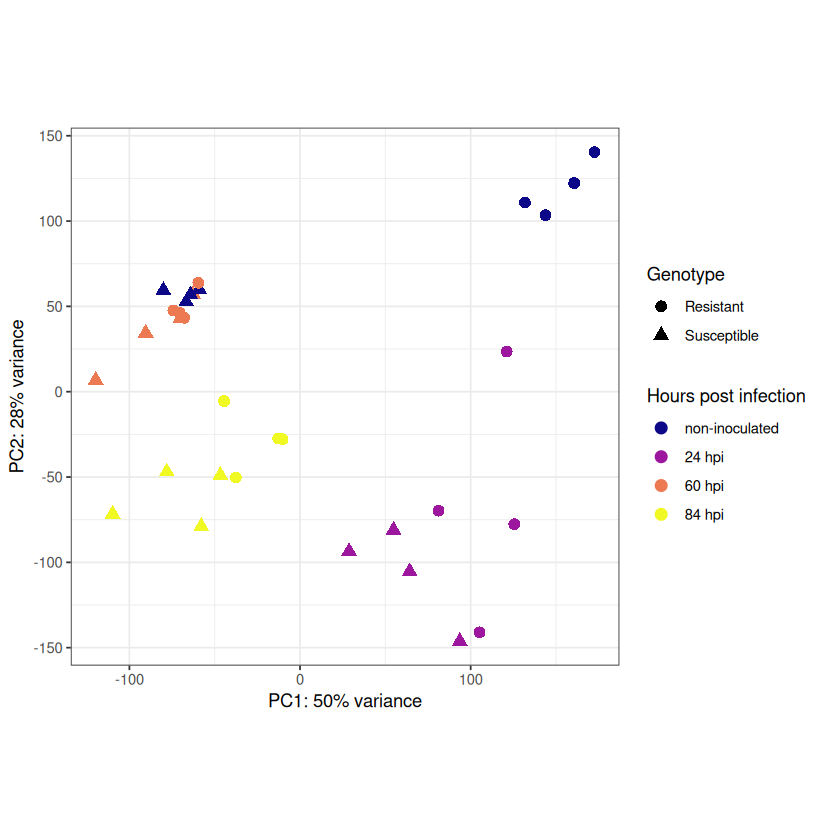

In [ ]:
library(ggplot2)

pca_tmm_norm <- ggplot(df_pca, aes(PC1, PC2, color = hpi, shape = response, linetype=tissue)) +
  geom_point(size = 3) +
  guides(col=guide_legend("Hours post infection"),
         shape=guide_legend("Genotype"))+
  xlab(paste0("PC1: ",percentVar[1],"% variance")) +
  ylab(paste0("PC2: ",percentVar[2],"% variance")) + 
  scale_colour_viridis_d(option = "C",labels=c("000HPI" = "non-inoculated", 
                                              "024HPI" = "24 hpi",
                                              "060HPI" = "60 hpi", 
                                              "084HPI" = "84 hpi"))+
  coord_fixed()+
  theme_bw()

pca_tmm_norm  

In [ ]:
ggsave("your_path/PCAdeseq_hypcotyl_tmm.pdf",
       pca_tmm_norm, device="pdf",dpi = 300,
       width = 14.85,
       height = 18,
       units = "cm")

ggsave("your_path/PCAdeseq_hypocotyl_tmm.png",
       pca_tmm_norm, device="png",dpi = 300,
       width = 14.85,
       height = 18,
       units = "cm")

ggsave("your_path/PCAdeseq_hypocotyl_tmm.tiff",
       pca_tmm_norm, device="tiff",dpi = 300,
       width = 14.85,
       height = 18,
       units = "cm")

In [ ]:
#HEATMAP_TMMLOG_top50
var_genes <- apply((logCPM), 1, var)

#top 50 genes more variable
top_genes <- head(order(var_genes, decreasing = TRUE), 50)
matriz_heatmap_50 <- logCPM[top_genes, ]



In [ ]:
annotation_col <- as.data.frame(colData(dds)[, c("response", "hpi", "tissue")])


In [ ]:
#needs to be TRUE
all(colnames(matriz_heatmap_50) == rownames(annotation_col))


[1] TRUE

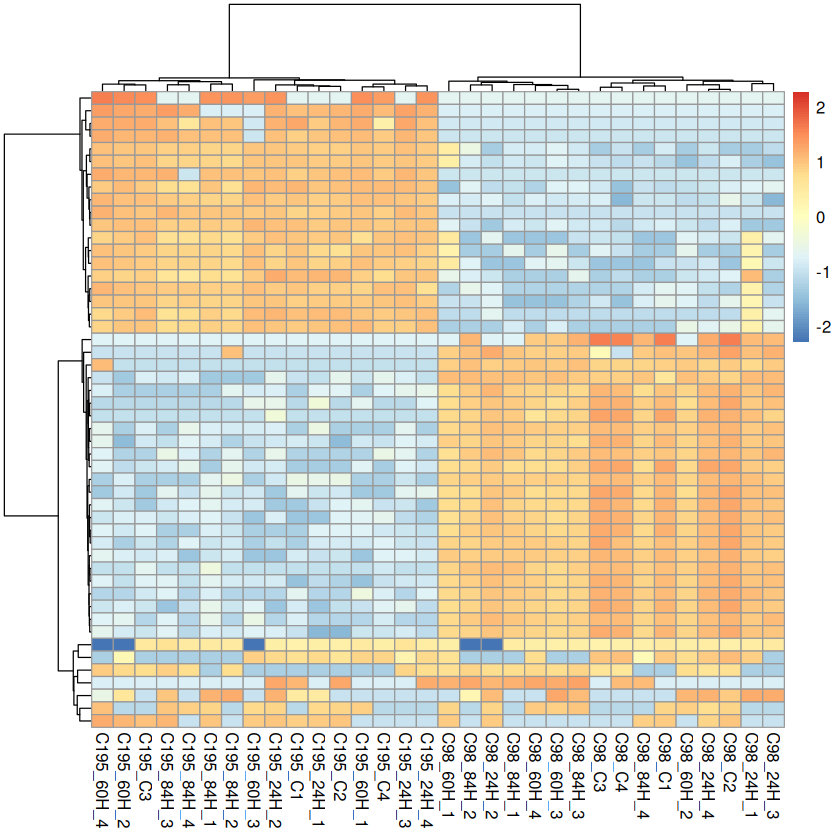

In [ ]:
library(pheatmap)

colors <- colorRampPalette(rev(brewer.pal(n = 7, name = "RdYlBu")))(100)

# Generate the heatmap with clustering
heatmap_tmm_50 <-pheatmap(matriz_heatmap_50, 
         scale = "row", 
         clustering_distance_rows = "euclidean", 
         clustering_distance_cols = "euclidean", 
         clustering_method = "ward.D2", 
         color = colors, 
         show_rownames = FALSE, 
         show_colnames = TRUE)


In [ ]:
save_pheatmap(heatmap_tmm_50, 
              filename="your_path/clustering_heatmap_tmm_50.png")
save_pheatmap_pdf(heatmap_tmm_50, 
                  filename="your_path/clustering_heatmap_tmm_50.pdf")
save_pheatmap_tiff(heatmap_tmm_50, 
                   filename="your_path/clustering_heatmap_tmm_50.tiff")

agg_record_1194789944 
                    2

agg_record_1194789944 
                    2

agg_record_1194789944 
                    2

In [ ]:
#HEATMAP_TMMLOG_test

var_genes_test <- apply(logCPM, 1, var)


matriz_heatmap_test <- logCPM[var_genes_test, ]


In [ ]:

annotation_col <- as.data.frame(colData(dds)[, c("response", "hpi", "tissue")])

In [ ]:
#needs to be True
all(colnames(matriz_heatmap_test) == rownames(annotation_col))


[1] TRUE

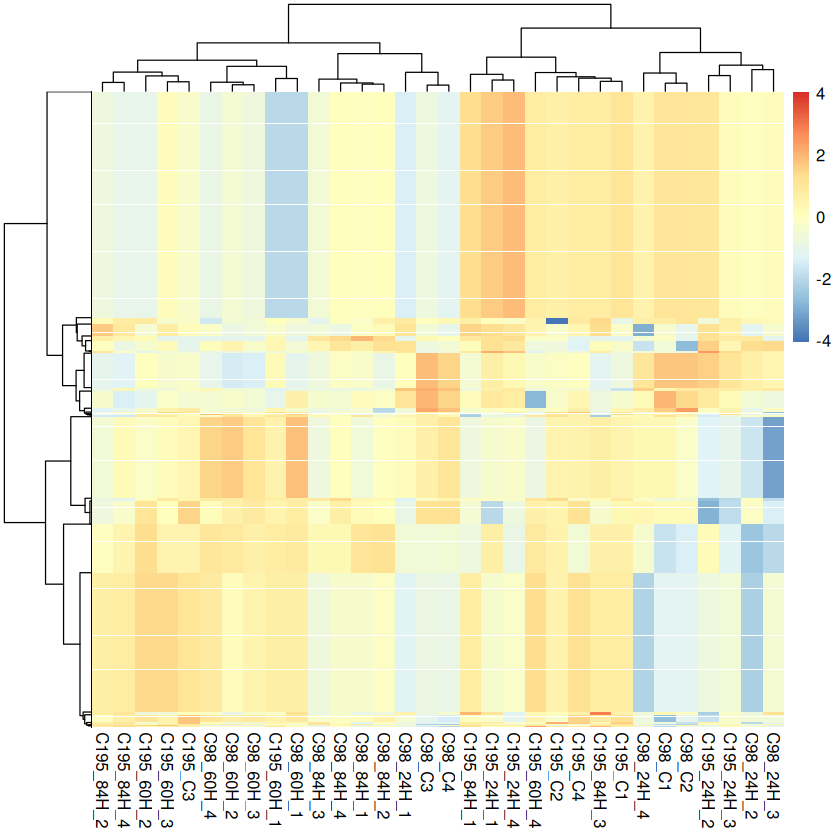

In [136]:
library(pheatmap)

# Define a color palette
colors <- colorRampPalette(rev(brewer.pal(n = 7, name = "RdYlBu")))(100)

# Generate the heatmap with clustering
heatmap_tmm_test <-pheatmap(matriz_heatmap_test, 
         scale = "row", 
         clustering_distance_rows = "euclidean", 
         clustering_distance_cols = "euclidean", 
         clustering_method = "ward.D2", 
         color = colors, 
         show_rownames = FALSE, 
         show_colnames = TRUE)

In [ ]:
save_pheatmap(heatmap_tmm_test, 
              filename="your_path/clustering_heatmap_tmm_test.png")
save_pheatmap_pdf(heatmap_tmm_test, 
                  filename="your_path/clustering_heatmap_tmm_test.pdf")
save_pheatmap_tiff(heatmap_tmm_test, 
                   filename="your_path/clustering_heatmap_tmm_test.tiff")

agg_record_1445471094 
                    2

agg_record_1445471094 
                    2

agg_record_1445471094 
                    2